<a href="https://colab.research.google.com/github/yox19/Smart-Phone-AI-Assisted-Fundus-Image-screening-/blob/main/AI_Fundus_Test_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

fundus_project/

├── preprocessing.py

                                 # Custom image pipeline (OpenCV)
├── train.py    

                                # Model definition & fast training script
├── app.py   

                                 # Flask server for local inference
└── test_client.py

                                   # Client script to test local images

In [ ]:
from pathlib import Path
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = (225, 225)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 4

CLASS_NAMES = [
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "normal",
]

MODEL_SAVE_PATH = "fundus_model.keras"

DATASET_NAME = "gunavenkatdoddi/eye-diseases-classification"


In [ ]:
import kagglehub
from pathlib import Path

download_path = kagglehub.dataset_download(DATASET_NAME)
base_folder_path = Path(download_path) / "dataset"

if not base_folder_path.exists():
    base_folder_path = Path(download_path)

image_paths = []
labels = []

for class_dir in sorted(base_folder_path.iterdir()):
    if not class_dir.is_dir():
        continue

    class_name = class_dir.name
    if class_name not in CLASS_NAMES:
        print(f"Skipping unexpected directory: {class_name}")
        continue

    for image_file in class_dir.iterdir():
        if image_file.is_file():
            image_paths.append(str(image_file))
            labels.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
})

print(f"Images: {len(df)}")
print(f"Classes: {sorted(df['label'].unique())}")
print(df["label"].value_counts())

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Images: 4217
Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
label
diabetic_retinopathy    1098
normal                  1074
cataract                1038
glaucoma                1007
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.25,
    random_state=SEED,
    stratify=df["label"],
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

print("\nTrain:")
print(train_df["label"].value_counts())

print("\nValidation:")
print(valid_df["label"].value_counts())

print("\nTest:")
print(test_df["label"].value_counts())


Train: (3162, 2)
Validation: (527, 2)
Test: (528, 2)

Train:
label
diabetic_retinopathy    823
normal                  805
cataract                779
glaucoma                755
Name: count, dtype: int64

Validation:
label
diabetic_retinopathy    137
normal                  134
cataract                130
glaucoma                126
Name: count, dtype: int64

Test:
label
diabetic_retinopathy    138
normal                  135
cataract                129
glaucoma                126
Name: count, dtype: int64


Data Preprocessing & Augmentation

Image preprocessing includes rescaling pixel values and applying augmentation techniques such as rotation, flipping, and zooming to improve model generalization.

Remove NLM




def apply_custom_preprocessing(img_array):

    img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)

    resized = cv2.resize(
        img_uint8,
        TARGET_SIZE,
        interpolation=cv2.INTER_AREA
    )

    lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    cl = clahe.apply(l)

    equalized = cv2.cvtColor(
        cv2.merge((cl, a, b)),
        cv2.COLOR_LAB2RGB
    )

    return equalized.astype(np.float32)


In [ ]:
def apply_custom_preprocessing(img_array):
    img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)

    resized = cv2.resize(
        img_uint8,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )

    lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    cl = clahe.apply(l)

    equalized = cv2.cvtColor(
        cv2.merge((cl, a, b)),
        cv2.COLOR_LAB2RGB
    )

    return equalized.astype(np.float32)


def preprocess_image_file(image_path_or_bytes, is_bytes=False):
    """Load an image from a path or bytes and apply canonical preprocessing."""
    if is_bytes:
        buffer = np.frombuffer(image_path_or_bytes, dtype=np.uint8)
        img = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    else:
        img = cv2.imread(str(image_path_or_bytes), cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError("Invalid or unreadable image.")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return apply_custom_preprocessing(img_rgb)

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    brightness_range=(0.95, 1.05),
    horizontal_flip=True,
    preprocessing_function=apply_custom_preprocessing,
)

eval_datagen = ImageDataGenerator(
    preprocessing_function=apply_custom_preprocessing,
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED,
)

valid_gen = eval_datagen.flow_from_dataframe(
    valid_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False,
)

test_gen = eval_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False,
)

print("Class mapping:", train_gen.class_indices)


Found 3162 validated image filenames belonging to 4 classes.
Found 527 validated image filenames belonging to 4 classes.
Found 528 validated image filenames belonging to 4 classes.
Class mapping: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}


🧠 Building and Compiling the CNN Model replaced with EfficientNetB3 for efficiency comparable performance

In [ ]:
def build_model():
    base_model = tf.keras.applications.EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )

    base_model.trainable = False

    inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        dtype="float32",
        name="class_probabilities",
    )(x)

    model = models.Model(inputs, outputs, name="fundus_efficientnetb3")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = build_model()
model.summary()


Model: "fundus_efficientnetb3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │         6,148 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,795,827 (41.18 MB)

 Trainable params: 9,220 (36.02 KB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=callbacks,
)

print(f"Best model saved to: {MODEL_SAVE_PATH}")


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5815 - loss: 1.1265
Epoch 1: val_loss improved from None to 0.76371, saving model to fundus_model.keras

Epoch 1: finished saving model to fundus_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.6727 - loss: 0.8865 - val_accuracy: 0.7002 - val_loss: 0.7637 - learning_rate: 0.0010
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.7512 - loss: 0.6438
Epoch 2: val_loss improved from 0.76371 to 0.52429, saving model to fundus_model.keras

Epoch 2: finished saving model to fundus_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 75s 753ms/step - accuracy: 0.7622 - loss: 0.6237 - val_accuracy: 0.8083 - val_loss: 0.5243 - learning_rate: 0.0010
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.8021 - loss: 0.5202
Epoch 3: val_loss improved from 0.52429 to 0.42910, saving model to fundus_model.keras

Epoch 3: finished saving model to fundus_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 76s 764ms/step -

In [ ]:
import os
import tensorflow as tf

# Ensure MODEL_SAVE_PATH is defined (e.g., 'fundus_model.keras')
# If you're running this in a new session, you might need to re-define:
# MODEL_SAVE_PATH = 'fundus_model.keras'

# Load the pre-trained model
MODEL_SAVE_PATH = '/content/drive/MyDrive/HOSPITAL ML/fundus_model.keras'

if not os.path.exists(MODEL_SAVE_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_SAVE_PATH}")
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
loaded_model.summary()

print(f"Model loaded successfully from: {MODEL_SAVE_PATH}")

Model: "fundus_efficientnetb3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │         6,148 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,814,269 (41.25 MB)

 Trainable params: 9,220 (36.02 KB)

 Non-trainable params: 10,786,607 (41.15 MB)

 Optimizer params: 18,442 (72.04 KB)

Model loaded successfully from: /content/drive/MyDrive/HOSPITAL ML/fundus_model.keras


🧪 Evaluating the Model with a Classification Report

In [ ]:
best_model = keras.models.load_model(MODEL_SAVE_PATH)

test_gen.reset()
probabilities = best_model.predict(test_gen, verbose=1)

y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
    )
)


17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step
Accuracy: 0.8674242424242424
Balanced accuracy: 0.8654022287490437

Classification report:
                      precision    recall  f1-score   support

            cataract     0.9111    0.9535    0.9318       129
diabetic_retinopathy     0.9338    0.9203    0.9270       138
            glaucoma     0.8812    0.7063    0.7841       126
              normal     0.7628    0.8815    0.8179       135

            accuracy                         0.8674       528
           macro avg     0.8722    0.8654    0.8652       528
        weighted avg     0.8720    0.8674    0.8662       528



🔍 Visualizing Model Performance with a Confusion Matrix

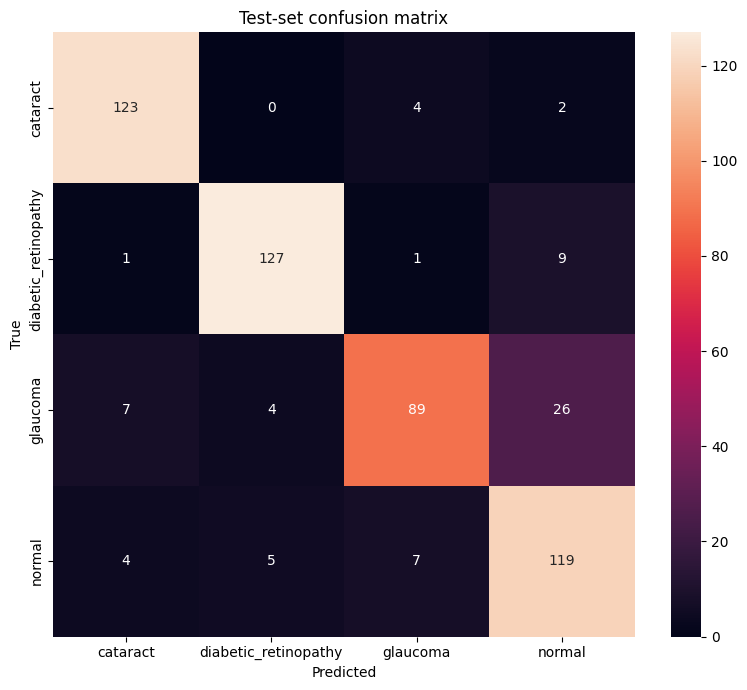

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test-set confusion matrix")
plt.tight_layout()
plt.show()


In [ ]:
def predict_image(image_path, model=best_model):
    processed = preprocess_image_file(image_path)
    x = np.expand_dims(processed, axis=0)

    probs = model.predict(x, verbose=0)[0]
    idx = int(np.argmax(probs))

    return {
        "prediction": CLASS_NAMES[idx],
        "confidence": float(probs[idx]),
        "probabilities": {
            CLASS_NAMES[i]: float(probs[i])
            for i in range(len(CLASS_NAMES))
        },
    }


example_path = test_df.iloc[0]["image_path"]
result = predict_image(example_path)
result


{'prediction': 'cataract',
 'confidence': 0.9729125499725342,
 'probabilities': {'cataract': 0.9729125499725342,
  'diabetic_retinopathy': 1.1594886018428952e-05,
  'glaucoma': 0.026940030977129936,
  'normal': 0.0001358401495963335}}

📈 Plotting Training vs. Validation Accuracy

The training history plots show how the model performed across epochs. By comparing training and validation loss and accuracy, we can evaluate model convergence, detect overfitting, and identify the best-performing epoch based on validation metrics.

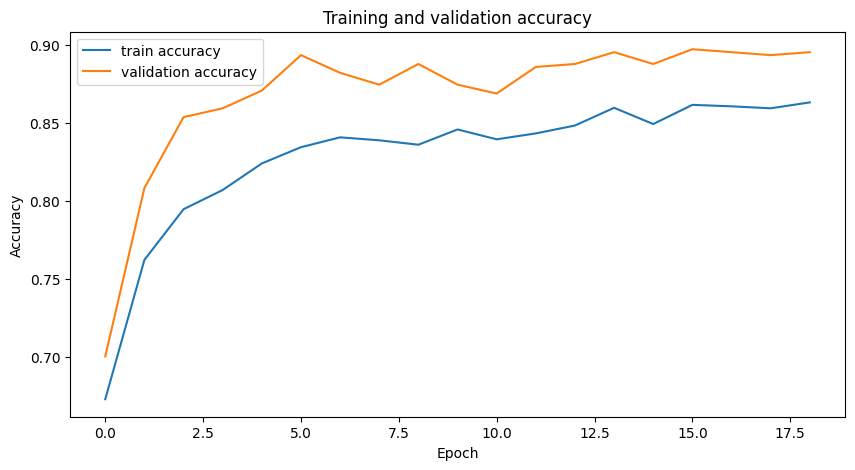

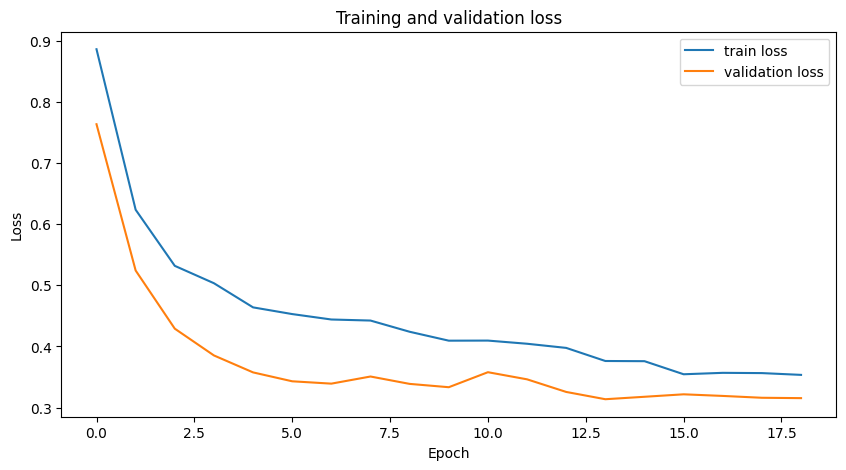

In [ ]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_df["accuracy"], label="train accuracy")
ax.plot(history_df["val_accuracy"], label="validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.set_title("Training and validation accuracy")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_df["loss"], label="train loss")
ax.plot(history_df["val_loss"], label="validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("Training and validation loss")
plt.show()


preprocessing.py

This module handles OpenCV contrast enhancement, denoising, resizing, and pixel rescaling so that training data and production inference match.

In [ ]:
import cv2
import numpy as np

TARGET_SIZE = (225, 225)

def apply_custom_preprocessing(img_array):
    """
    Applies custom preprocessing to a single image array (RGB, uint8):
    1. Resizing to 225x225
    2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    3. Fast Non-Local Means Denoising
    4. Rescaling pixel values to [0, 1]
    """
    # Ensure standard uint8 format for OpenCV
    img_uint8 = img_array.astype(np.uint8)

    # 1. Resize to 225x225
    resized = cv2.resize(img_uint8, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    # 2. Histogram Equalization on Luminance Channel
    lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    equalized = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # 3. Noise Reduction Filter
    denoised = cv2.fastNnlMeansDenoisingColored(equalized, None, h=3, hColor=3, templateWindowSize=7, searchWindowSize=21)

    # 4. Rescale to [0, 1]
    normalized = denoised.astype(np.float32) / 255.0
    return normalized

def preprocess_image_file(image_path_or_bytes, is_bytes=False):
    """Utility to load and preprocess an image file or byte stream for inference."""
    if is_bytes:
        nparr = np.frombuffer(image_path_or_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    else:
        img = cv2.imread(image_path_or_bytes)

    if img is None:
        raise ValueError("Invalid image file or byte buffer.")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return apply_custom_preprocessing(img_rgb)

3. app.py

Flask deployment script. Pre-loads the TensorFlow model globally to serve fast predictions

In [ ]:
app_py_content = '''
from flask import Flask, request, jsonify
import tensorflow as tf
import numpy as np
import cv2

IMG_SIZE = (225, 225)
CLASSES = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
MODEL_PATH = "fundus_model.keras"

def apply_custom_preprocessing(img_array):
    img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)

    resized = cv2.resize(
        img_uint8,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )

    lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    cl = clahe.apply(l)

    equalized = cv2.cvtColor(
        cv2.merge((cl, a, b)),
        cv2.COLOR_LAB2RGB
    )

    return equalized.astype(np.float32)


def preprocess_image_file(image_path_or_bytes, is_bytes=False):
    if is_bytes:
        buffer = np.frombuffer(image_path_or_bytes, dtype=np.uint8)
        img = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    else:
        img = cv2.imread(str(image_path_or_bytes), cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError("Invalid or unreadable image.")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return apply_custom_preprocessing(img_rgb)


app = Flask(__name__)

print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
_ = model.predict(np.zeros((1, *IMG_SIZE, 3)), verbose=0)
print("Model ready for requests.")

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "healthy"}), 200

@app.route("/predict", methods=["POST"])
def predict():
    if "file" not in request.files:
        return jsonify({"error": "No image file provided in request"}), 400

    file = request.files["file"]
    try:
        image_bytes = file.read()
        processed_img = preprocess_image_file(image_bytes, is_bytes=True)
        input_tensor = np.expand_dims(processed_img, axis=0)
        preds = model.predict(input_tensor, verbose=0)[0]
        class_idx = int(np.argmax(preds))

        return jsonify({
            "prediction": CLASSES[class_idx],
            "confidence": float(preds[class_idx]),
            "class_probabilities": {CLASSES[i]: float(preds[i]) for i in range(len(CLASSES))}
        }), 200

    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

with open('app.py', 'w') as f:
    f.write(app_py_content)

print('app.py created successfully.')

app.py created successfully.


In [ ]:
from flask import Flask, request, jsonify
import tensorflow as tf
import numpy as np
import cv2 # Added cv2 import

# Define global variables needed for preprocessing and model
IMG_SIZE = (225, 225) # Defined here for self-containment of the script
CLASSES = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"] # Using 'CLASSES' as in the original `app.py`
MODEL_PATH = "fundus_model.keras" # Corrected from .h5 to .keras

# Preprocessing functions (copied from cell xZthuhEP3qzG)
def apply_custom_preprocessing(img_array):
    img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)

    resized = cv2.resize(
        img_uint8,
        IMG_SIZE, # Now correctly references IMG_SIZE defined above
        interpolation=cv2.INTER_AREA
    )

    lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    cl = clahe.apply(l)

    equalized = cv2.cvtColor(
        cv2.merge((cl, a, b)),
        cv2.COLOR_LAB2RGB
    )

    return equalized.astype(np.float32)


def preprocess_image_file(image_path_or_bytes, is_bytes=False):
    """Load an image from a path or bytes and apply canonical preprocessing."""
    if is_bytes:
        buffer = np.frombuffer(image_path_or_bytes, dtype=np.uint8)
        img = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    else:
        img = cv2.imread(str(image_path_or_bytes), cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError("Invalid or unreadable image.")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return apply_custom_preprocessing(img_rgb)


app = Flask(__name__) # Fixed `name` to `__name__` as standard Flask practice

# Load model globally once on server start
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)

# Warmup execution
_ = model.predict(np.zeros((1, *IMG_SIZE, 3)), verbose=0) # Use IMG_SIZE here as well
print("Model ready for requests.")

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "healthy"}), 200

@app.route("/predict", methods=["POST"])
def predict():
    if "file" not in request.files:
        return jsonify({"error": "No image file provided in request"}), 400

    file = request.files["file"]
    try:
        image_bytes = file.read()

        # Apply preprocessing
        processed_img = preprocess_image_file(image_bytes, is_bytes=True)
        input_tensor = np.expand_dims(processed_img, axis=0)

        # Run inference
        preds = model.predict(input_tensor, verbose=0)[0]
        class_idx = int(np.argmax(preds))

        return jsonify({
            "prediction": CLASSES[class_idx],
            "confidence": float(preds[class_idx]),
            "class_probabilities": {CLASSES[i]: float(preds[i]) for i in range(len(CLASSES))}
        }), 200

    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == "__main__": # Fixed `name` to `__name__`
    app.run(host="0.0.0.0", port=5000, debug=False)


Loading model...
Model ready for requests.
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
import subprocess
import time
import requests

# 1. Kill any existing background Flask or ngrok processes
!pkill -f "app.py"
!pkill -f ngrok

# 2. Start app.py in the background and write output to a log file
log_file = open("app.log", "w")
flask_process = subprocess.Popen(["python3", "app.py"], stdout=log_file, stderr=subprocess.STDOUT)

# 3. Poll the server until it finishes loading TensorFlow and starts responding
print("Starting Flask server in background...")
server_ready = False
for i in range(30):
    try:
        res = requests.get("http://127.0.0.1:5000/health", timeout=1)
        if res.status_code == 200:
            print(f"✔ Flask server is live and ready! (Took {i+1} seconds)")
            server_ready = True
            break
    except requests.exceptions.RequestException:
        time.sleep(1)

if not server_ready:
    print("❌ Server failed to start within 30 seconds. Checking app.log:")
    with open("app.log", "r") as f:
        print(f.read())

Starting Flask server in background...
✔ Flask server is live and ready! (Took 29 seconds)


4. test_client.py

Script to test your deployed Flask application with a local test image.

In [ ]:
import requests

SERVER_URL = "http://127.0.0.1:5000/predict"
IMAGE_PATH = '/content/drive/MyDrive/HOSPITAL ML/AI Fundus Screening project /_73_2704407.jpg'
def test_inference(image_path):
    with open(image_path, "rb") as img:
        files = {"file": img}
        response = requests.post(SERVER_URL, files=files)

    if response.status_code == 200:
        print("Inference Result:")
        print(response.json())
    else:
        print(f"Error {response.status_code}:", response.text)

if __name__ == "__main__":
    test_inference(IMAGE_PATH)

Inference Result:
{'class_probabilities': {'cataract': 0.0021268310956656933, 'diabetic_retinopathy': 0.1327115297317505, 'glaucoma': 0.8203669786453247, 'normal': 0.04479464888572693}, 'confidence': 0.8203669786453247, 'prediction': 'glaucoma'}
